<a href="https://colab.research.google.com/github/Mohanee28/06July2024/blob/main/PCA%20analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# The MNIST dataset is a well-known dataset in the field of machine learning and computer vision. It consists of a large collection of handwritten digits, specifically 28x28 pixel grayscale images of handwritten digits from 0 to 9. The dataset is widely used for training and testing machine learning and deep learning models, especially for tasks like digit recognition and image classification.

Here are some key characteristics and details about the MNIST dataset:

1. **Size**: The MNIST dataset contains a total of 70,000 images, divided into two main subsets:
   - Training Set: 60,000 images
   - Test Set: 10,000 images

2. **Digits**: Each image in the dataset represents a single handwritten digit from 0 to 9.

3. **Image Size**: Each image is 28 pixels in height and 28 pixels in width, resulting in a total of 784 pixels per image.

4. **Labeling**: Each image is associated with a corresponding label or target, indicating the digit it represents. The labels are integers ranging from 0 to 9.

5. **Use**: The MNIST dataset is often used as a benchmark for evaluating the performance of machine learning algorithms and deep neural networks. It serves as a standard dataset for tasks related to image classification and digit recognition.

6. **Challenges**: While MNIST is relatively simple compared to more complex datasets, it still presents challenges in machine learning, such as handling variations in handwriting styles and dealing with noise and variations in image quality.

7. **Availability**: The MNIST dataset is readily available and can be accessed through various machine learning libraries and platforms, making it a popular choice for educational purposes and research.

Researchers and machine learning practitioners have developed and tested a wide range of algorithms on the MNIST dataset, which has led to significant advancements in the field of image recognition and classification. While MNIST has been widely used, more challenging datasets like CIFAR-10, CIFAR-100, and ImageNet have also gained popularity to address more complex image classification tasks. Nonetheless, MNIST remains a foundational dataset for learning and experimenting with image data in the context of machine learning and deep learning.

In [2]:
#MNIST

In [3]:
from sklearn import datasets

In [4]:
dir(datasets)

['__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__getattr__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_arff_parser',
 '_base',
 '_california_housing',
 '_covtype',
 '_kddcup99',
 '_lfw',
 '_olivetti_faces',
 '_openml',
 '_rcv1',
 '_samples_generator',
 '_species_distributions',
 '_svmlight_format_fast',
 '_svmlight_format_io',
 '_twenty_newsgroups',
 'clear_data_home',
 'dump_svmlight_file',
 'fetch_20newsgroups',
 'fetch_20newsgroups_vectorized',
 'fetch_california_housing',
 'fetch_covtype',
 'fetch_file',
 'fetch_kddcup99',
 'fetch_lfw_pairs',
 'fetch_lfw_people',
 'fetch_olivetti_faces',
 'fetch_openml',
 'fetch_rcv1',
 'fetch_species_distributions',
 'get_data_home',
 'load_breast_cancer',
 'load_diabetes',
 'load_digits',
 'load_files',
 'load_iris',
 'load_linnerud',
 'load_sample_image',
 'load_sample_images',
 'load_svmlight_file',
 'load_svmlight_files',
 'load_wine',
 'make_biclusters',
 'make_blobs',
 'make_checkerboard

In [5]:
from sklearn.datasets import load_digits

In [6]:
digit = load_digits()

In [7]:
digit

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]]),
 'target': array([0, 1, 2, ..., 8, 9, 8]),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7',
  'pixel_5_0',
  'pixel_5_1',
 

In [8]:
df = pd.DataFrame(digit.data)
df

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,4.0,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0


In [9]:
 #Enumerate example
letters = ['a', 'b', 'c', 'd', 'e']
for index, letter in enumerate(letters):
   print(f' index {index}, {letter}')

 index 0, a
 index 1, b
 index 2, c
 index 3, d
 index 4, e


In [10]:
#zip function example
numbers = [1,2,3,4,5]
letters = ['a', 'b', 'c', 'd', 'e']
zipped = zip(numbers, letters)
print(zipped)

In [11]:
for number, letter in zipped:
  print(f'index:{number}, letters: {letter}')

index:1, letters: a
index:2, letters: b
index:3, letters: c
index:4, letters: d
index:5, letters: e


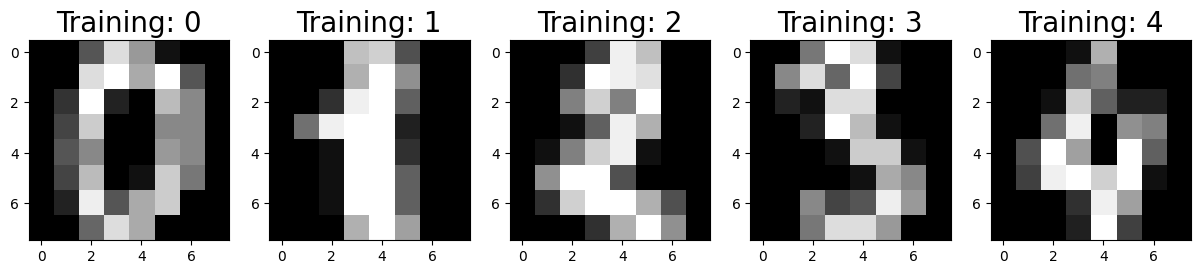

In [12]:
plt.figure(figsize=(15,4))
for index, (image, label) in enumerate(zip(digit.data[0:5], digit.target[0:5])):
  plt.subplot(1,5,index+1)
  plt.imshow(np.reshape(image, (8,8)), cmap = plt.cm.gray)
  plt.title(f'Training: {label}', fontsize = 20)

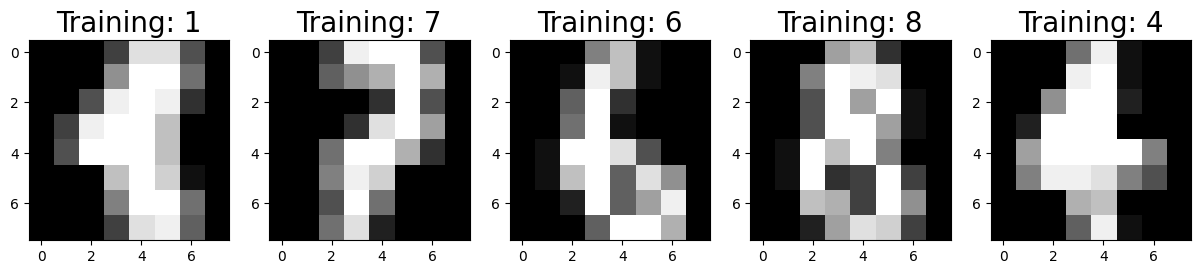

In [13]:
plt.figure(figsize= (15,4))
for index, (image, label) in enumerate(zip(digit.data[221:226], digit.target[221:226])):
  plt.subplot(1,5,index+1)
  plt.imshow(np.reshape(image,(8,8)), cmap = plt.cm.gray)
  plt.title(f'Training: {label}', fontsize = 20)

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
0,1797.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
1,1797.0,0.303840,0.907192,0.0,0.0,0.0,0.0,8.0
2,1797.0,5.204786,4.754826,0.0,1.0,4.0,9.0,16.0
3,1797.0,11.835838,4.248842,0.0,10.0,13.0,15.0,16.0
4,1797.0,11.848080,4.287388,0.0,10.0,13.0,15.0,16.0
...,...,...,...,...,...,...,...,...
59,1797.0,12.089037,4.374694,0.0,11.0,13.0,16.0,16.0
60,1797.0,11.809126,4.933947,0.0,10.0,14.0,16.0,16.0
61,1797.0,6.764051,5.900623,0.0,0.0,6.0,12.0,16.0
62,1797.0,2.067891,4.090548,0.0,0.0,0.0,2.0,16.0


In [15]:
digit.data.shape

(1797, 64)

In [16]:
digit.images.shape

(1797, 8, 8)

In [17]:
x=digit.data
y=digit.target

In [18]:
X_std = StandardScaler().fit_transform(x)
X_std

array([[ 0.        , -0.33501649, -0.04308102, ..., -1.14664746,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -1.09493684, ...,  0.54856067,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -1.09493684, ...,  1.56568555,
         1.6951369 , -0.19600752],
       ...,
       [ 0.        , -0.33501649, -0.88456568, ..., -0.12952258,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -0.67419451, ...,  0.8876023 ,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649,  1.00877481, ...,  0.8876023 ,
        -0.26113572, -0.19600752]])

In [19]:
X_std.shape

(1797, 64)

In [20]:
x1 = X_std.T

In [21]:
cov_mat = np.cov(X_std.T)
cov_mat

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  1.00055679,  0.55692803, ..., -0.02988686,
         0.02656195, -0.04391324],
       [ 0.        ,  0.55692803,  1.00055679, ..., -0.04120565,
         0.07263924,  0.08256908],
       ...,
       [ 0.        , -0.02988686, -0.04120565, ...,  1.00055679,
         0.64868875,  0.26213704],
       [ 0.        ,  0.02656195,  0.07263924, ...,  0.64868875,
         1.00055679,  0.62077355],
       [ 0.        , -0.04391324,  0.08256908, ...,  0.26213704,
         0.62077355,  1.00055679]])

In [22]:
eig_val, eig_vec = np.linalg.eig(cov_mat)
eig_val

array([7.34477606, 5.83549054, 5.15396118, 3.96623597, 2.9663452 ,
       2.57204442, 2.40600941, 2.06867355, 1.82993314, 1.78951739,
       1.69784616, 1.57287889, 1.38870781, 1.35933609, 1.32152536,
       1.16829176, 1.08368678, 0.99977862, 0.97438293, 0.90891242,
       0.82271926, 0.77631014, 0.71155675, 0.64552365, 0.59527399,
       0.5765018 , 0.52673155, 0.5106363 , 0.48686381, 0.45560107,
       0.44285155, 0.42230086, 0.3991063 , 0.39110111, 0.36094517,
       0.34860306, 0.3195963 , 0.05037444, 0.29406627, 0.27692285,
       0.06328961, 0.258273  , 0.24783029, 0.2423566 , 0.07635394,
       0.08246812, 0.09018543, 0.09840876, 0.10250434, 0.11188655,
       0.11932898, 0.12426371, 0.13321081, 0.14311427, 0.217582  ,
       0.15818474, 0.16875236, 0.20799593, 0.17612894, 0.2000909 ,
       0.18983516, 0.        , 0.        , 0.        ])

In [23]:
eig_vec

array([[ 0.        ,  0.        ,  0.        , ...,  1.        ,
         0.        ,  0.        ],
       [ 0.18223392, -0.04702701,  0.02358821, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.285868  , -0.0595648 , -0.05679875, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.103198  ,  0.24261778, -0.02227952, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.1198106 ,  0.16508926,  0.10036559, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.07149362,  0.07132924,  0.09244589, ...,  0.        ,
         0.        ,  0.        ]])

In [24]:
total = sum(eig_val)
var_exp = [float((i/total)*100) for i in sorted(eig_val, reverse = True)]
var_exp

[12.033916097734904,
 9.561054403097883,
 8.444414892624566,
 6.498407907524167,
 4.860154875966403,
 4.214119869271944,
 3.9420828035674003,
 3.3893809246383264,
 2.998221011625232,
 2.9320025512522068,
 2.781805463550326,
 2.5770550925819995,
 2.2753033157642486,
 2.227179739514353,
 2.1652294318492435,
 1.9141666064421259,
 1.7755470851681938,
 1.6380692742844212,
 1.5964601688623428,
 1.4891911870878194,
 1.3479695658179378,
 1.2719313702347599,
 1.1658373505919493,
 1.0576465985363224,
 0.9753159471981139,
 0.9445589897319981,
 0.8630138269707229,
 0.8366428536685183,
 0.7976932484112456,
 0.7464713709260611,
 0.725582151370274,
 0.691911245481183,
 0.6539085355726172,
 0.640792573845988,
 0.5913841117223424,
 0.571162405223525,
 0.5236368034166339,
 0.48180758644514254,
 0.45371925985845096,
 0.42316275323278085,
 0.4060530699790386,
 0.39708480827582743,
 0.3564933031426177,
 0.34078718147030074,
 0.32783533528795417,
 0.3110320073453569,
 0.28857529410893434,
 0.276489263523546

In [25]:
cum_var_exp = np.cumsum(var_exp)
cum_var_exp

array([ 12.0339161 ,  21.5949705 ,  30.03938539,  36.5377933 ,
        41.39794818,  45.61206805,  49.55415085,  52.94353177,
        55.94175279,  58.87375534,  61.6555608 ,  64.23261589,
        66.50791921,  68.73509895,  70.90032838,  72.81449499,
        74.59004207,  76.22811135,  77.82457152,  79.3137627 ,
        80.66173227,  81.93366364,  83.09950099,  84.15714759,
        85.13246353,  86.07702252,  86.94003635,  87.77667921,
        88.57437245,  89.32084382,  90.04642598,  90.73833722,
        91.39224576,  92.03303833,  92.62442244,  93.19558485,
        93.71922165,  94.20102924,  94.6547485 ,  95.07791125,
        95.48396432,  95.88104913,  96.23754243,  96.57832961,
        96.90616495,  97.21719696,  97.50577225,  97.78226151,
        98.04143645,  98.27591946,  98.49417632,  98.69777395,
        98.89328638,  99.07660488,  99.24455127,  99.40578733,
        99.55355002,  99.68866843,  99.81376918,  99.91746491,
       100.        , 100.        , 100.        , 100.  

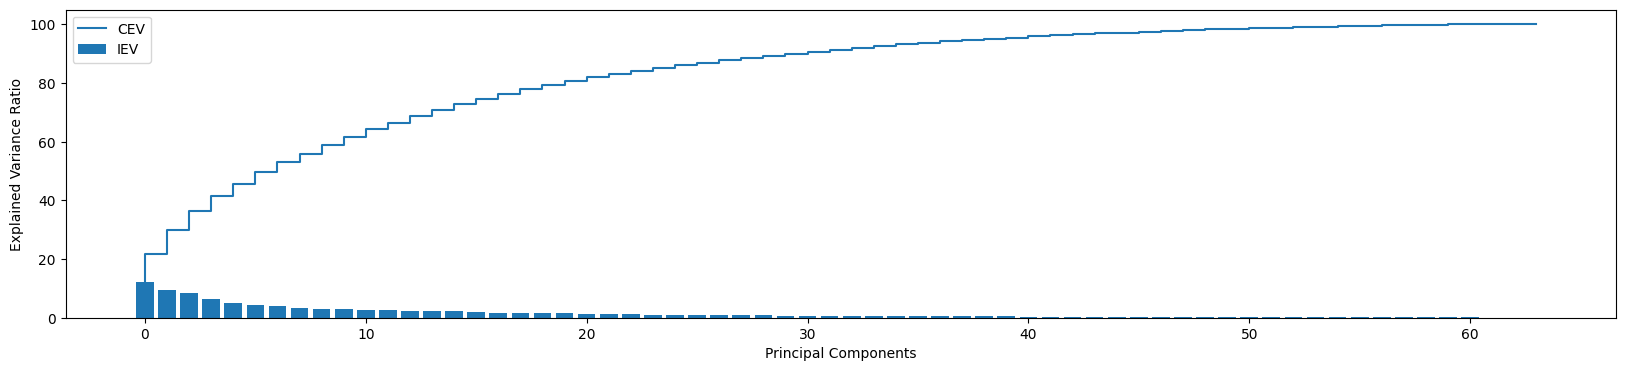

In [26]:
plt.figure(figsize = (20,4))
plt.bar(range(len(cum_var_exp)), var_exp, label = 'IEV')
plt.step(range(len(cum_var_exp)), cum_var_exp, label = 'CEV')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.legend(loc = 'best')
plt.show()


In [27]:
x_train, x_test, y_train, y_test = train_test_split(X_std, y, train_size = 0.8)

In [28]:
x_train.shape

(1437, 64)

In [29]:
x_test.shape

(360, 64)

In [30]:
pca = PCA(n_components = 25)
pca_x_train = pca.fit_transform(x_train)
pca_x_test = pca.transform(x_test)

In [31]:
pca_x_test.shape

(360, 25)

In [32]:
pca_x_train.shape

(1437, 25)

In [33]:
dt = DecisionTreeClassifier().fit(pca_x_train, y_train)
predicted = dt.predict(pca_x_test)

In [34]:
predicted

array([8, 5, 7, 3, 6, 2, 0, 9, 3, 9, 5, 0, 6, 8, 8, 0, 6, 0, 2, 2, 9, 0,
       0, 5, 3, 3, 7, 2, 3, 1, 6, 4, 1, 8, 3, 1, 1, 1, 1, 3, 3, 4, 5, 5,
       6, 6, 4, 0, 6, 5, 1, 5, 1, 4, 0, 5, 0, 8, 6, 2, 8, 3, 1, 1, 0, 4,
       0, 8, 4, 2, 8, 0, 9, 7, 0, 0, 2, 1, 7, 5, 7, 5, 8, 6, 0, 1, 2, 5,
       0, 8, 2, 2, 9, 5, 4, 4, 3, 3, 3, 6, 8, 8, 2, 8, 3, 7, 9, 5, 8, 9,
       5, 5, 7, 1, 8, 6, 0, 6, 4, 4, 5, 9, 8, 2, 5, 1, 9, 4, 8, 0, 3, 8,
       9, 2, 5, 6, 8, 7, 7, 7, 8, 4, 3, 0, 1, 2, 9, 8, 2, 8, 5, 9, 9, 0,
       2, 3, 7, 3, 6, 5, 6, 2, 4, 6, 0, 6, 4, 1, 5, 8, 5, 1, 6, 8, 3, 8,
       7, 6, 9, 8, 6, 0, 6, 9, 7, 2, 4, 5, 8, 4, 1, 4, 6, 6, 4, 5, 6, 5,
       3, 9, 7, 2, 4, 9, 2, 8, 5, 2, 9, 5, 9, 0, 9, 1, 2, 4, 3, 2, 0, 9,
       6, 4, 6, 3, 9, 9, 9, 3, 4, 4, 3, 8, 4, 5, 1, 4, 4, 6, 1, 3, 1, 8,
       5, 3, 9, 9, 1, 4, 7, 2, 5, 4, 1, 4, 3, 1, 8, 4, 6, 9, 5, 9, 3, 2,
       9, 3, 5, 6, 4, 7, 4, 1, 6, 7, 4, 3, 2, 0, 6, 8, 3, 0, 4, 8, 5, 6,
       5, 7, 5, 5, 6, 0, 7, 1, 8, 4, 9, 0, 9, 3, 3,

In [35]:
y_test

array([8, 5, 7, 3, 6, 2, 0, 9, 3, 9, 9, 0, 6, 8, 8, 0, 6, 0, 3, 2, 9, 0,
       0, 5, 8, 6, 7, 9, 3, 1, 6, 4, 1, 8, 3, 1, 1, 1, 1, 1, 8, 4, 5, 1,
       6, 6, 4, 0, 6, 5, 1, 5, 1, 4, 0, 5, 0, 2, 6, 2, 8, 3, 9, 1, 0, 5,
       0, 5, 4, 2, 8, 0, 9, 7, 0, 0, 8, 8, 7, 5, 7, 5, 8, 6, 0, 1, 2, 9,
       0, 8, 2, 2, 9, 5, 4, 4, 3, 3, 3, 6, 8, 3, 2, 6, 3, 4, 9, 5, 8, 9,
       5, 5, 7, 1, 2, 6, 0, 6, 4, 4, 5, 9, 8, 2, 5, 1, 5, 4, 8, 0, 3, 8,
       9, 2, 5, 6, 8, 9, 7, 7, 8, 4, 3, 9, 2, 2, 5, 8, 2, 8, 5, 9, 5, 0,
       2, 3, 7, 3, 6, 3, 6, 2, 4, 6, 0, 6, 4, 1, 5, 8, 5, 1, 6, 8, 2, 9,
       7, 6, 9, 8, 6, 0, 6, 9, 7, 2, 4, 5, 7, 4, 2, 4, 6, 6, 8, 5, 6, 5,
       3, 9, 7, 2, 4, 9, 2, 8, 5, 2, 9, 5, 9, 0, 8, 4, 2, 4, 3, 2, 9, 3,
       6, 4, 6, 8, 9, 9, 9, 9, 4, 4, 7, 8, 4, 5, 1, 4, 4, 6, 1, 3, 2, 9,
       5, 3, 9, 9, 1, 4, 7, 2, 5, 4, 3, 4, 3, 1, 3, 4, 6, 9, 5, 9, 3, 2,
       9, 3, 5, 6, 4, 7, 4, 1, 6, 7, 4, 1, 2, 0, 6, 7, 3, 0, 4, 8, 5, 6,
       5, 7, 5, 5, 4, 0, 7, 1, 8, 4, 9, 0, 9, 3, 3,

In [36]:
accuracy_score(predicted, y_test)

0.8444444444444444

In [37]:
def get_misclassified_index(predicted, y_test):
  misclassification = []
  for index, (predicted, actual) in enumerate(zip(predicted, y_test)):
    if predicted != actual:
      misclassification.append(index)
  return misclassification

In [38]:
misclassification = get_misclassified_index(predicted, y_test)

In [39]:
len(misclassification)

56

In [40]:
misclassification[0:5]

[10, 18, 24, 25, 27]

In [41]:
def plot_misclassification (misclassification):
  plt.figure(figsize = (15,4))
  for index,wrong in enumerate(misclassification[0:5]):
    plt.subplot(1,5,index+1)
    plt.imshow(np.reshape(pca_x_test[wrong], (5,5)), cmap = plt.cm.gray)
    plt.title('predicted:{}, Actual:{}'.format(predicted[wrong],y_test[wrong]))

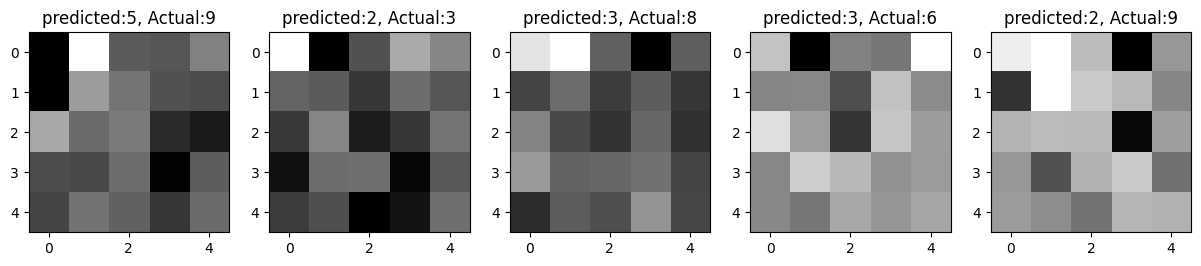

In [42]:
plot_misclassification (misclassification)

In [45]:
def get_classified_index(predicted, y_test):
  classification = []
  for index, (predicted, actual) in enumerate(zip(predicted, y_test)):
    if predicted == actual:
      classification.append(index)
  return classification

In [49]:
classifications = get_classified_index(predicted, y_test)

In [51]:
len(classifications)

304

In [71]:
def plot_classification (classifications):
  plt.figure(figsize = (15,4))
  for index, wrong in enumerate(classifications[0:5]):
    plt.subplot(1,5,index+1)
    plt.imshow(np.reshape(pca_x_test[wrong],(5,5)), cmap= plt.cm.gray)
    plt.title('predicted:{}, Actual:{}'.format(predicted[wrong],y_test[wrong]))

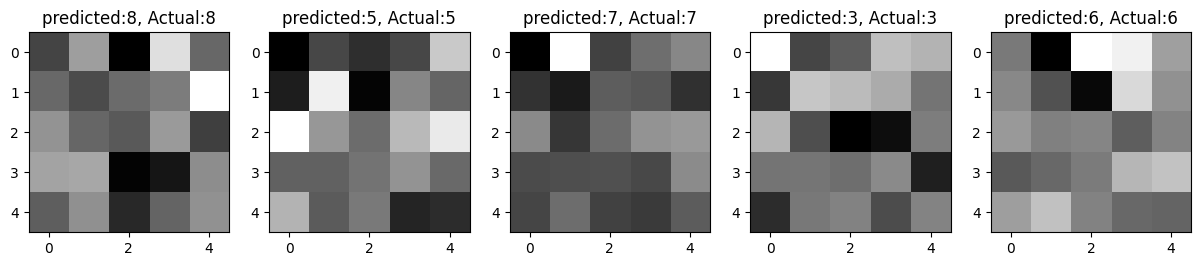

In [72]:
plot_classification(classifications)